In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

subset_dir = "medical_datasets/tropical_infectious_diseases_cohort"

# 1. Load patient case reports
cases_df = pd.read_csv(os.path.join(subset_dir, "cases.csv"))

# 2. Load image-level metadata
# 2. Load image-level metadata (JSON Lines format)
images_df = pd.read_json(
    os.path.join(subset_dir, "image_metadata.json"), lines=True
)

print(f"Loaded {len(cases_df):,} patients and {len(images_df):,} images.")
print("\n--- Cases Columns ---")
print(cases_df.columns.tolist())
print("\n--- Image Metadata Columns ---")
print(images_df.columns.tolist())

Loaded 2,893 patients and 6,082 images.

--- Cases Columns ---
['case_id', 'pmcid', 'gender', 'age', 'case_text']

--- Image Metadata Columns ---
['file_id', 'file', 'file_path', 'main_image', 'case_id', 'license', 'file_size', 'split_during_preprocessing', 'caption', 'image_type', 'image_subtype', 'radiology_region', 'radiology_region_granular', 'radiology_view', 'ml_labels_for_supervised_classification', 'gt_labels_for_semisupervised_classification']


--- Gender Breakdown ---
gender
Male       1637
Female     1182
Unknown      74
Name: count, dtype: int64

--- Age Summary ---
count    2778.000000
mean       40.151908
std        22.122729
min         0.000000
25%        24.000000
50%        40.000000
75%        57.000000
max        94.000000
Name: age, dtype: float64

--- Case Presentation Word Count Summary ---
count    2893.000000
mean      571.502592
std       314.101936
min        17.000000
25%       360.000000
50%       519.000000
75%       724.000000
90%       938.000000
95%      1119.800000
max      3694.000000
Name: word_count, dtype: float64


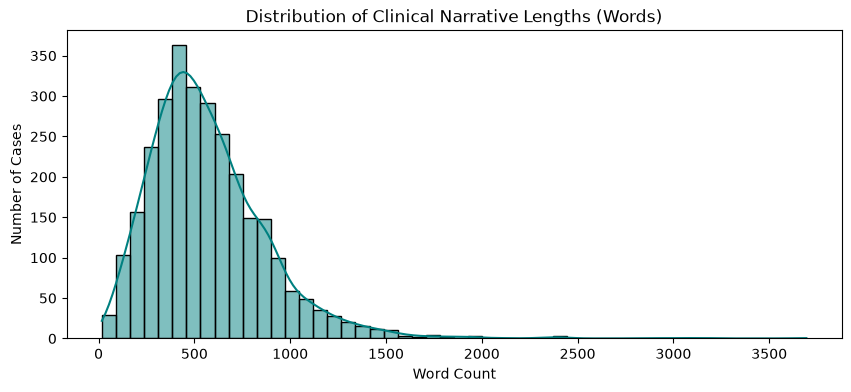

In [4]:
# Demographics
print("--- Gender Breakdown ---")
print(cases_df['gender'].value_counts(dropna=False))

print("\n--- Age Summary ---")
print(cases_df['age'].describe())

# Compute case text word length
cases_df['word_count'] = cases_df['case_text'].apply(lambda x: len(str(x).split()))

print("\n--- Case Presentation Word Count Summary ---")
print(cases_df['word_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]))

# Distribution plot
plt.figure(figsize=(10, 4))
sns.histplot(cases_df['word_count'], bins=50, kde=True, color='teal')
plt.title("Distribution of Clinical Narrative Lengths (Words)")
plt.xlabel("Word Count")
plt.ylabel("Number of Cases")
plt.show()

In [5]:
# 1. High-level modality distribution
if 'image_type' in images_df.columns:
    print("--- Top High-Level Modalities (image_type) ---")
    print(images_df['image_type'].value_counts().head(10))

# 2. Specific imaging subtype (X-ray, CT, MRI, ultrasound, histology, etc.)
if 'image_subtype' in images_df.columns:
    print("\n--- Top Specific Subtypes (image_subtype) ---")
    print(images_df['image_subtype'].value_counts().head(15))

# 3. Anatomical region
if 'radiology_region' in images_df.columns:
    print("\n--- Top Anatomical Regions ---")
    print(images_df['radiology_region'].value_counts().head(10))

# 4. Image views / projections
if 'radiology_view' in images_df.columns:
    print("\n--- Top Views / Projections ---")
    print(images_df['radiology_view'].value_counts().head(10))

--- Top High-Level Modalities (image_type) ---
image_type
radiology             3096
pathology             1429
medical_photograph     815
ophthalmic_imaging     272
chart                  248
endoscopy              166
electrography           56
Name: count, dtype: int64

--- Top Specific Subtypes (image_subtype) ---
image_subtype
ct                          1415
mri                          889
h&e                          637
x_ray                        506
immunostaining               427
skin_photograph              395
other_medical_photograph     381
chart                        248
ultrasound                   196
fundus_photograph            112
giemsa                        86
gi_endoscopy                  85
oct                           80
pet                           77
airway_endoscopy              69
Name: count, dtype: int64

--- Top Anatomical Regions ---
radiology_region
thorax        1331
head           724
abdomen        512
lower_limb     166
neck           164
p

--- Identified Disease Distribution (Patient Level) ---
identified_diseases
Tuberculosis              2537
Dengue                     203
Malaria                    163
Leishmaniasis              124
Leptospirosis              124
Schistosomiasis             52
Scrub Typhus                47
Filariasis / Helminths      44
Zika / Chikungunya          35
Melioidosis                 29
Amoebiasis                  11
Name: count, dtype: int64


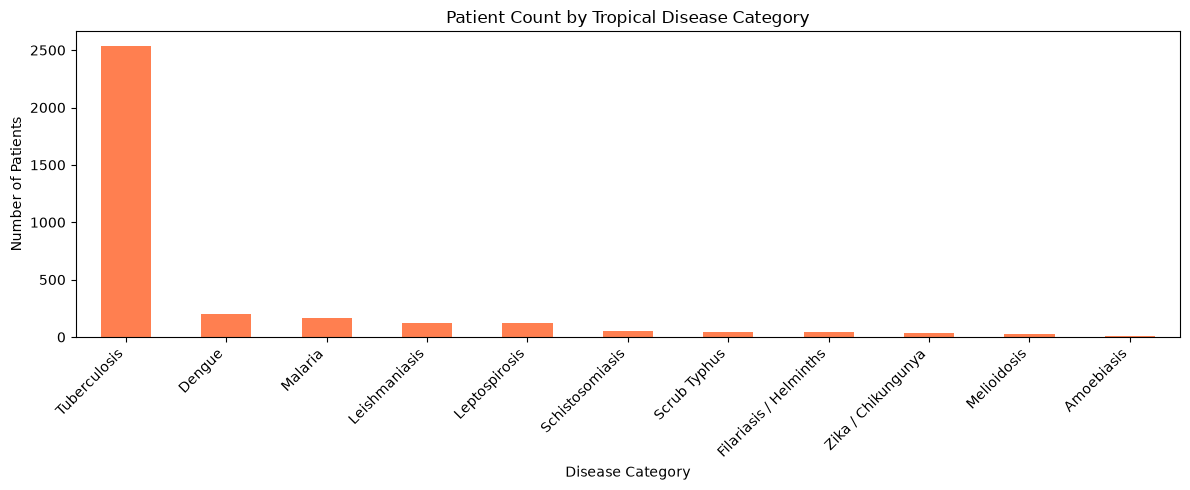

In [6]:
pathogens_to_track = {
    "Tuberculosis": ["tuberculosis", "mycobacterium", "tb", "acid-fast", "pott"],
    "Dengue": ["dengue", "dhf", "dengue shock"],
    "Malaria": ["malaria", "plasmodium", "falciparum", "vivax"],
    "Melioidosis": ["melioidosis", "burkholderia pseudomallei"],
    "Leishmaniasis": ["leishmania", "kala-azar", "donovani"],
    "Schistosomiasis": ["schistosoma", "schistosomiasis", "bilharzia"],
    "Leptospirosis": ["leptospir", "weil disease"],
    "Scrub Typhus": ["scrub typhus", "tsutsugamushi", "orientia"],
    "Zika / Chikungunya": ["zika", "chikungunya"],
    "Amoebiasis": ["amoebiasis", "amebiasis", "entamoeba histolytica"],
    "Filariasis / Helminths": ["filariasis", "strongyloides", "echinococcus", "cysticercosis"]
}

def identify_diseases(text):
    text_lower = str(text).lower()
    matched = []
    for disease, terms in pathogens_to_track.items():
        if any(term in text_lower for term in terms):
            matched.append(disease)
    return matched if matched else ["Other / Unclassified"]

# Apply across patients
cases_df['identified_diseases'] = cases_df['case_text'].apply(identify_diseases)

# Flatten and count
disease_counts = cases_df.explode('identified_diseases')['identified_diseases'].value_counts()

print("--- Identified Disease Distribution (Patient Level) ---")
print(disease_counts)

plt.figure(figsize=(12, 5))
disease_counts.plot(kind='bar', color='coral')
plt.title("Patient Count by Tropical Disease Category")
plt.xlabel("Disease Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# 1. Unsplit vs Split captions
if 'split_during_preprocessing' in images_df.columns:
    print("--- Caption Slicing Breakdown ---")
    print(images_df['split_during_preprocessing'].value_counts())
    pct_clean = (images_df['split_during_preprocessing'] == False).mean() * 100
    print(f"Pristine, unsplit captions: {pct_clean:.1f}%")

# 2. Check physical image file existence on disk
image_dir = os.path.join(subset_dir, "images")
if os.path.exists(image_dir):
    actual_files = os.listdir(image_dir)
    print(f"\nPhysical image files present on disk: {len(actual_files):,}")
    if len(actual_files) > 0:
        print("Sample image filename:", actual_files[0])

--- Caption Slicing Breakdown ---
split_during_preprocessing
False    3965
True     2117
Name: count, dtype: int64
Pristine, unsplit captions: 65.2%

Physical image files present on disk: 9
Sample image filename: PMC7
